In [ ]:
## Open in Colab
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/COAST-Lab/Sensing-Secchi-Disk/tree/main/Jupyter_Notebook/intro_01_pythonecosystem.ipynb)
https://github.com/

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import datetime
import linecache
import re
import os
from matplotlib import pyplot as plt

In [2]:
# Code used to import data from Google Drive


from google.colab import drive
drive.mount('/content/drive')
# Name of filepath for gathering file. DO NOT CHANGE UNLESS YOU KNOW WHAT YOU ARE DOING
base_path = "/content/drive/MyDrive/SSD Information Intake Form  (File responses)/Secchi Disk Raw Data"
# Raw data file used for analysis. Change when analyzing a different file.
target_filename = "260129-01-A016.txt"

File_1 = f"{base_path}/{target_filename}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
base_path = "/content/drive/MyDrive/SSD Information Intake Form  (File responses)/Secchi Disk Raw Data"#Extract from file: Secchi Depth (SD), Forel–Ule (FU),
#pH, serial number of device (SN), latitude, longitude and date
SD        = linecache.getline(File_1, 1)
SD        = float(re.findall(r'\d+', SD)[0]) if re.findall(r'\d+', SD) else 0.0
FU        = linecache.getline(File_1, 2)
FU        = float(re.findall(r'\d+', FU)[0]) if re.findall(r'\d+', FU) else 0.0
pH        = linecache.getline(File_1, 3)
pH        = float(re.findall(r'\d+', pH)[0]) if re.findall(r'\d+', pH) else 0.0
SN        = linecache.getline(File_1, 4)
SN        = float(re.findall(r'\d+', SN)[0]) if re.findall(r'\d+', SN) else 0.0
Latitude  = linecache.getline(File_1, 5)
Latitude  = float(re.findall(r'-?\d+\.?\d+', Latitude)[0]) if re.findall(r'-?\d+\.?\d+', Latitude) else 0.0
Longitude = linecache.getline(File_1, 6)
Longitude = float(re.findall(r'-?\d+\.?\d+', Longitude)[0]) if re.findall(r'-?\d+\.?\d+', Longitude) else 0.0
Date      = linecache.getline(File_1, 7)
Date      = re.findall(r'\d+', Date)
Year      = float(Date[0]) if len(Date) > 0 else 0.0
Month     = float(Date[1]) if len(Date) > 1 else 0.0
Day       = float(Date[2]) if len(Date) > 2 else 0.0

In [4]:
# Extract profile data
df = pd.read_csv(File_1, header=7)
Time_SS           = df.loc[:,'Time (UTC)'].to_numpy()
Pressure_SS       = df.loc[:,' Pressure (mbar) MS5803'].to_numpy()
Temp_MS5803_SS    = df.loc[:,' Temp (deg C) MS5803'].to_numpy()
E415nm_SS         = df.loc[:,' ED 415nm'].to_numpy()
E445nm_SS         = df.loc[:,' ED 445nm'].to_numpy()
E480nm_SS         = df.loc[:,' ED 480nm'].to_numpy()
E515nm_SS         = df.loc[:,' ED 515nm'].to_numpy()
E555nm_SS         = df.loc[:,' ED 555nm'].to_numpy()
E590nm_SS         = df.loc[:,' ED 590nm'].to_numpy()
E630nm_SS         = df.loc[:,' ED 630nm'].to_numpy()
E680nm_SS         = df.loc[:,' ED 680nm'].to_numpy()
EPAR_SS           = df.loc[:,' ED Clear'].to_numpy()
ENIR_SS           = df.loc[:,' ED NIR'].to_numpy()
Temp_TH_SS        = df.loc[:,' Temp (deg C) TMP117'].to_numpy()

In [5]:
#Compute atmospheric pressure assuming first 5 readings are in atmosphere
ATMOS_P           = np.median(Pressure_SS[0:5])

In [6]:
#Correct differences in sensor distance
#Compute depth (assuming pressure = depth)
Depth_SS          = ((Pressure_SS - ATMOS_P)/100.)
#Correct for distance between temperature sensor and pressure
Depth_SS_T        = Depth_SS + 0.007
#Correct for distance between light sensor and pressure
Depth_SS_L        = Depth_SS - 0.02

In [7]:
#Sort time to decimal hour and compute seconds (DATA_SEC) and second since start (DATA_SEC0)
HH = np.empty([len(Time_SS)])
MM = np.empty([len(Time_SS)])
SS = np.empty([len(Time_SS)])
for j in range(len(Time_SS)):
    time = datetime.datetime.strptime(Time_SS[j], '%H:%M:%S')
    HH[j] = time.hour
    MM[j] = time.minute
    SS[j] = time.second
DATA_SEC = (HH*3600.) + (MM*60.) + (SS)
DATA_SEC0         = DATA_SEC - DATA_SEC[0]

In [8]:
#Print extracted data
print('Year = ', Year)
print('Month = ', Month)
print('Day = ', Day)
print('Latitude (degs N) = ', Latitude)
print('Longitude (degs E) = ', Longitude)
print('Secchi depth (cm) = ', SD)
print('Forel Ule = ', FU)
print('pH = ', pH)

Year =  2026.0
Month =  1.0
Day =  29.0
Latitude (degs N) =  34.1414
Longitude (degs E) =  -77.86684
Secchi depth (cm) =  1.0
Forel Ule =  0.0
pH =  19.0


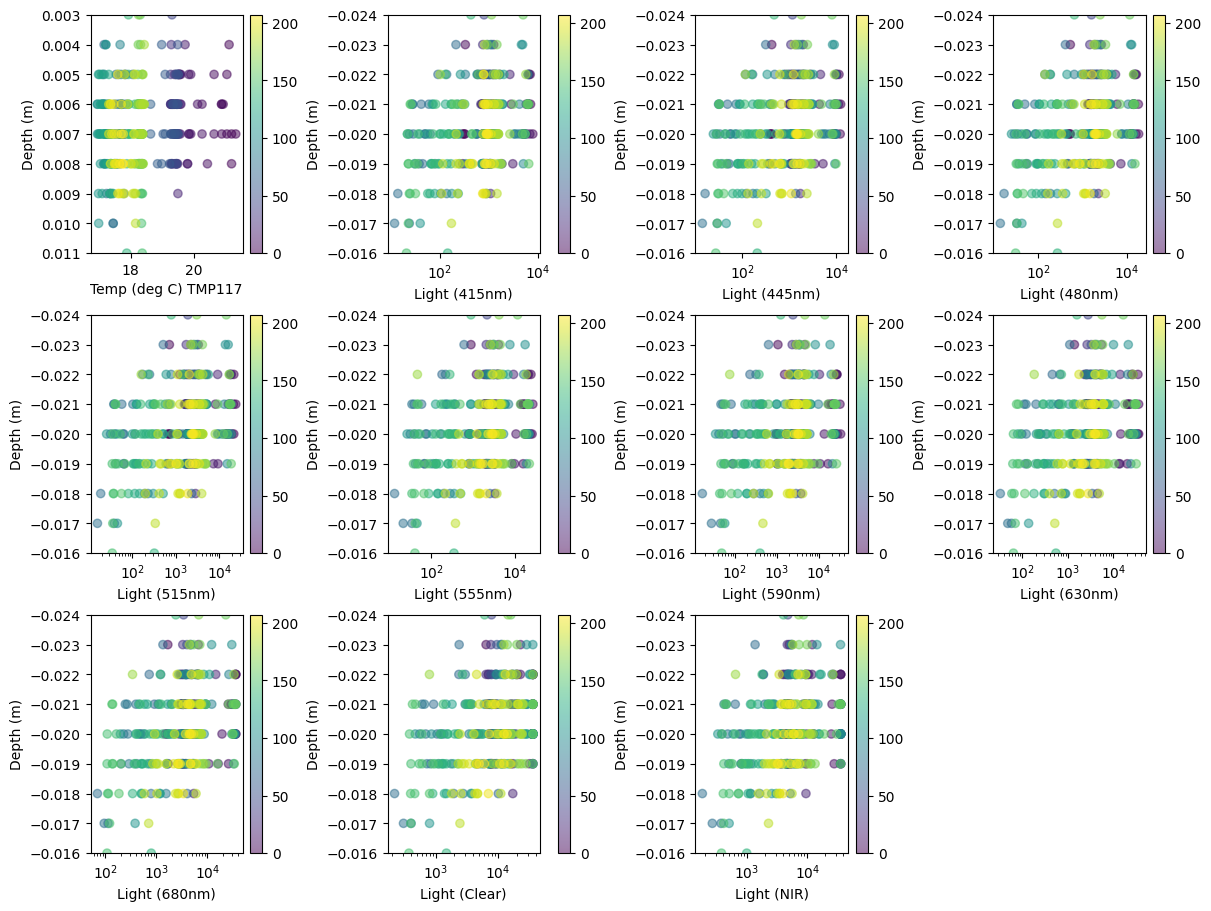

In [9]:
fig, axs = plt.subplots(3, 4, figsize=(12, 9), constrained_layout=True)

# unpack axes
ax1, ax2, ax3, ax4 = axs[0]
ax5, ax6, ax7, ax8 = axs[1]
ax9, ax10, ax11, ax12 = axs[2]

# Temperature map
im1 = ax1.scatter(Temp_TH_SS, Depth_SS_T, c=DATA_SEC0, alpha=0.5)
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel('Temp (deg C) TMP117')
ax1.set_ylim([np.max(Depth_SS_T), np.min(Depth_SS_T)])
fig.colorbar(im1, ax=ax1)

def plot_light(ax, x, label):
    x = np.array(x)
    mask = x > 0
    x = x[mask]
    depth = Depth_SS_L[mask]
    color = DATA_SEC0[mask]

    im = ax.scatter(x, depth, c=color, alpha=0.5)
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel(label)
    ax.set_ylim([np.max(depth), np.min(depth)])
    ax.set_xscale('log')

    fig.colorbar(im, ax=ax)

#Wavelength Plots
plot_light(ax2, E415nm_SS, 'Light (415nm)')
plot_light(ax3, E445nm_SS, 'Light (445nm)')
plot_light(ax4, E480nm_SS, 'Light (480nm)')
plot_light(ax5, E515nm_SS, 'Light (515nm)')
plot_light(ax6, E555nm_SS, 'Light (555nm)')
plot_light(ax7, E590nm_SS, 'Light (590nm)')
plot_light(ax8, E630nm_SS, 'Light (630nm)')
plot_light(ax9, E680nm_SS, 'Light (680nm)')
plot_light(ax10, EPAR_SS, 'Light (Clear)')
plot_light(ax11, ENIR_SS, 'Light (NIR)')

ax12.set_visible(False)

plt.show()

In [10]:
!pip install gspread

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import numpy as np

# asks for permission
creds, _ = default()
gc = gspread.authorize(creds)

# Create/open spreadsheet
sheet_name = "Secchi Cast Log"

try:
    sheet = gc.open(sheet_name)
except:
    sheet = gc.create(sheet_name)

worksheet = sheet.sheet1

# Clean average function
def compute_avg(x):
    x = np.array(x)
    x = x[(x > 0) & (~np.isnan(x))]
    return float(np.mean(x)) if len(x) > 0 else np.nan

# Optional depth filter
mask = Depth_SS_L < 2

# Compute averages
Avg_415 = compute_avg(E415nm_SS[mask])
Avg_445 = compute_avg(E445nm_SS[mask])
Avg_480 = compute_avg(E480nm_SS[mask])
Avg_515 = compute_avg(E515nm_SS[mask])
Avg_555 = compute_avg(E555nm_SS[mask])
Avg_590 = compute_avg(E590nm_SS[mask])
Avg_630 = compute_avg(E630nm_SS[mask])
Avg_680 = compute_avg(E680nm_SS[mask])
Avg_Clear = compute_avg(EPAR_SS[mask])
Avg_NIR = compute_avg(ENIR_SS[mask])

# Build row
row = [
    Year, Month, Day,
    Latitude, Longitude,
    SD, pH,
    Avg_415, Avg_445, Avg_480, Avg_515,
    Avg_555, Avg_590, Avg_630, Avg_680,
    Avg_Clear, Avg_NIR
]

headers = [
    "Year", "Month", "Day",
    "Latitude", "Longitude",
    "Secchi Depth", "pH",
    "Avg_415", "Avg_445", "Avg_480", "Avg_515",
    "Avg_555", "Avg_590", "Avg_630", "Avg_680",
    "Avg_Clear", "Avg_NIR"
]

# Write to sheet (append)
existing = worksheet.get_all_values()

if len(existing) == 0:
    worksheet.append_row(headers)
elif existing[0] != headers:
    worksheet.insert_row(headers, 1)

worksheet.append_row(row)

# Success print
print("Data successfully written to Google Sheets!")
print(f"Sheet name: {sheet_name}")
print(f"Open here: {sheet.url}")

Data successfully written to Google Sheets!
Sheet name: Secchi Cast Log
Open here: https://docs.google.com/spreadsheets/d/1obhuUZTNGBgPYuogSQvVy6Evc6fiQ98nyosXDm3F8sY
